# 01 — Model Development: Importance Engine v1 + Resolution Engine v1
> 10 September 2026 — Experienced AI/ML Engineer (Anik).
> Synthetic-only notebook: runs top-to-bottom with NumPy/Pandas/Matplotlib. No nuScenes download, no Kaggle credentials, no trained segmentation model.

Pipeline: `RegionFeatures -> Importance Engine v1 -> Resolution Engine v1 -> Adaptive 2.5D Mapper` (mapper consumed downstream; not reimplemented here).

## 1. Imports and configuration

In [19]:
import sys
from pathlib import Path

# Resolve repo root so `src/` + `config/` import both locally and in Colab.
# Local: notebook lives in <root>/notebooks/. Colab: repo cloned, same layout.
candidates = [Path.cwd(), Path.cwd() / '..', Path('..'), Path('.')]
REPO_ROOT = None
for c in candidates:
    if ((c / 'src' / 'importance_engine.py').exists() and (c / 'config' / 'importance_config.py').exists()):
        REPO_ROOT = c.resolve()
        break
if REPO_ROOT is None:
    REPO_ROOT = Path.cwd().resolve() if (Path.cwd() / 'src').exists() else Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT))
print('REPO_ROOT:', REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass, asdict
from typing import Dict, List, Optional

print('Python:', sys.version)
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)

from config.importance_config import MAX_DISTANCE, WEIGHTS, UNCERTAINTY_BOOST, validate_importance_config
from config.resolution_config import RESOLUTION_LEVELS, RESOLUTION_VALUES, RESOLUTION_THRESHOLDS_MAP
from src.importance_engine import ImportanceEngine, clip01, normalize_distance
from src.resolution_engine import ResolutionEngine
from src.data_types import RegionFeatures

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-6, 'weights must sum to 1.0'
validate_importance_config()
print('MAX_DISTANCE =', MAX_DISTANCE)
print('WEIGHTS =', WEIGHTS)
print('UNCERTAINTY_BOOST =', UNCERTAINTY_BOOST)
print('RESOLUTION_LEVELS =', RESOLUTION_LEVELS)
print('RESOLUTION_VALUES =', RESOLUTION_VALUES)
print('[PASS] Weight configuration valid')


REPO_ROOT: C:\Users\SARKAR\Documents\Default Project
Python: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.4.4
Pandas: 3.0.2
MAX_DISTANCE = 100.0
WEIGHTS = {'distance': 0.3, 'semantic': 0.3, 'terrain': 0.15, 'dynamic': 0.15, 'uncertainty': 0.1}
UNCERTAINTY_BOOST = 0.15
RESOLUTION_LEVELS = [(0.75, 0.05), (0.5, 0.1), (0.25, 0.2), (0.0, 0.5)]
RESOLUTION_VALUES = {'very_high': 0.05, 'high': 0.1, 'medium': 0.2, 'low': 0.5}
[PASS] Weight configuration valid


## 2. Project feature contract
Reuses the 9-September `RegionFeatures` interface unchanged (`src/data_types.py`). Primary v1 inputs: `distance` (m), `semantic_importance`, `terrain_complexity` (`RegionFeatures.roughness`), `dynamic_relevance`, `uncertainty`, `confidence` [0,1]. `confidence` is validated + preserved but has **no independent v1 weight** (see §5 / docs).

In [20]:
import inspect
print(inspect.getsource(RegionFeatures))
# Field-name bridge used by this notebook (existing contract preserved, never renamed):
print('terrain_complexity  <->  RegionFeatures.roughness')
print('distance (m) is physical until normalize_distance() inside the engine')


@dataclass
class RegionFeatures:
    """Region-level features. Main structure consumed by the Importance Engine.

    Already normalized [0,1]: semantic_importance, confidence, roughness,
    dynamic_relevance, uncertainty. Physical/raw: distance (m), elevation (m),
    point_density (points/region), x/y (m centroid).
    """

    region_id: int
    x: float
    y: float
    distance: float
    elevation: float
    roughness: float
    point_density: float
    semantic_label: str
    semantic_importance: float
    confidence: float
    dynamic_relevance: float
    uncertainty: float
    point_count: int

    def to_legacy_region(self, points: np.ndarray):
        """Compat view matching the existing Stage-1 engine signature.

        Existing engines (01_Model_Development.ipynb SyntheticRegion and
        stage1_stage2_combined.py RegionFeatures) expect attributes:
        region_id, semantic_class, points (Nx4), distance_m,
        semantic_importance, terrain_complexity, dynamic_rele

## 3. Mathematical model
$$D = \\mathrm{clip}_{[0,1]}(1 - d / d_{max}), \\quad d_{max} = 100$$
$$I_{base} = w_d D + w_s S + w_t T + w_m M + w_u U$$
$$I_{safe} = \\min(1, I_{base} + \\lambda U), \\quad \\lambda = 0.15$$
with $(w_d, w_s, w_t, w_m, w_u) = (0.30, 0.30, 0.15, 0.15, 0.10)$. Weights/thresholds are **initial prototype engineering parameters** (not optimized, not benchmarks).

In [21]:
print(f"D = 1 - d/{MAX_DISTANCE}, clipped to [0,1]")
print(f"I_base = {WEIGHTS['distance']}*D + {WEIGHTS['semantic']}*S + {WEIGHTS['terrain']}*T"
      f" + {WEIGHTS['dynamic']}*M + {WEIGHTS['uncertainty']}*U")
print(f"I_safe = min(1, I_base + {UNCERTAINTY_BOOST}*U)")
print('Resolution: >=0.75 -> 0.05m | >=0.50 -> 0.10m | >=0.25 -> 0.20m | else -> 0.50m')


D = 1 - d/100.0, clipped to [0,1]
I_base = 0.3*D + 0.3*S + 0.15*T + 0.15*M + 0.1*U
I_safe = min(1, I_base + 0.15*U)
Resolution: >=0.75 -> 0.05m | >=0.50 -> 0.10m | >=0.25 -> 0.20m | else -> 0.50m


## 4. Normalization functions
`clip01` constrains to [0,1] (rejects NaN/inf); `normalize_distance` maps metres -> closeness score.

In [22]:
for d in [0, 10, 50, 75, 100, 150]:
    print(f'{d:>4} m -> D = {normalize_distance(float(d), MAX_DISTANCE):.2f}')
assert normalize_distance(0) == 1.0
assert normalize_distance(10) == 0.9
assert normalize_distance(50) == 0.5
assert normalize_distance(75) == 0.25
assert normalize_distance(100) == 0.0
assert normalize_distance(150) == 0.0
assert clip01(-0.5) == 0.0 and clip01(1.5) == 1.0
print('[PASS] Distance normalization')


   0 m -> D = 1.00
  10 m -> D = 0.90
  50 m -> D = 0.50
  75 m -> D = 0.25
 100 m -> D = 0.00
 150 m -> D = 0.00
[PASS] Distance normalization


## 5. Importance Engine v1
Weighted fusion + uncertainty safety bonus. `confidence` is validated and carried on the result but does **not** enter the v1 formula (`uncertainty` carries the perception-quality term — no double counting). Exposes `distance_score`, `base_importance`, `final_importance`.

In [23]:
imp_engine = ImportanceEngine()  # loads config/importance_config.py (no magic numbers)
res_engine = ResolutionEngine()  # loads config/resolution_config.py
print('weights:', imp_engine.weights)
print('max_distance:', imp_engine.max_distance, '| lambda:', imp_engine.lambda_uncertainty)
print('levels:', res_engine.levels)


weights: {'distance': 0.3, 'semantic': 0.3, 'terrain': 0.15, 'dynamic': 0.15, 'uncertainty': 0.1}
max_distance: 100.0 | lambda: 0.15
levels: [(0.75, 0.05), (0.5, 0.1), (0.25, 0.2), (0.0, 0.5)]


## 6. Resolution Engine v1
Deterministic, boundary-inclusive mapping of `final_importance ∈ [0,1]` -> cell size. API `select_resolution()` with spec-name alias `assign_resolution()`.

In [24]:
for v in [0.00, 0.24, 0.25, 0.49, 0.50, 0.74, 0.75, 1.00]:
    a = res_engine.select_resolution(v)
    b = res_engine.assign_resolution(v)  # spec-name alias, identical behaviour
    assert a == b
    print(f'I = {v:.2f} -> {a:.2f} m')
expected = {0.00: 0.50, 0.24: 0.50, 0.25: 0.20, 0.49: 0.20, 0.50: 0.10, 0.74: 0.10, 0.75: 0.05, 1.00: 0.05}
for v, e in expected.items():
    assert res_engine.assign_resolution(v) == e, (v, e)
print('[PASS] Resolution boundary mapping')


I = 0.00 -> 0.50 m
I = 0.24 -> 0.50 m
I = 0.25 -> 0.20 m
I = 0.49 -> 0.20 m
I = 0.50 -> 0.10 m
I = 0.74 -> 0.10 m
I = 0.75 -> 0.05 m
I = 1.00 -> 0.05 m
[PASS] Resolution boundary mapping


## 7. Synthetic test regions
Controlled synthetic `RegionFeatures` — **not** real nuScenes data, **not** model output. Uses the existing `RegionFeatures` structure (with `roughness` = terrain complexity).

In [25]:
def make_region(region_id, x, y, distance, semantic_label, semantic_importance,
                terrain_complexity, dynamic_relevance, uncertainty, confidence,
                elevation=0.0, point_density=50.0, point_count=50):
    return RegionFeatures(region_id=region_id, x=x, y=y, distance=float(distance),
        elevation=float(elevation), roughness=float(terrain_complexity),
        point_density=float(point_density), semantic_label=semantic_label,
        semantic_importance=float(semantic_importance), confidence=float(confidence),
        dynamic_relevance=float(dynamic_relevance), uncertainty=float(uncertainty),
        point_count=int(point_count))

synthetic_regions = [
    make_region(1, 3.0, 4.0, 5,  'vehicle',       1.0, 0.30, 1.0, 0.10, 0.90),  # Region 1: near vehicle
    make_region(2, 70.0, 0.0, 70, 'pedestrian',   1.0, 0.20, 1.0, 0.10, 0.90),  # Region 2: distant pedestrian
    make_region(3, 70.0, 5.0, 70, 'road',         0.1, 0.10, 0.0, 0.05, 0.95),  # Region 3: distant road
    make_region(4, 30.0, 0.0, 30, 'rough_terrain', 0.5, 1.00, 0.1, 0.40, 0.60),  # Region 4: rough terrain
    make_region(5, 95.0, 0.0, 95, 'empty_ground', 0.1, 0.05, 0.0, 0.00, 1.00),  # Region 5: far background
]
for r in synthetic_regions:
    print(r)


RegionFeatures(region_id=1, x=3.0, y=4.0, distance=5.0, elevation=0.0, roughness=0.3, point_density=50.0, semantic_label='vehicle', semantic_importance=1.0, confidence=0.9, dynamic_relevance=1.0, uncertainty=0.1, point_count=50)
RegionFeatures(region_id=2, x=70.0, y=0.0, distance=70.0, elevation=0.0, roughness=0.2, point_density=50.0, semantic_label='pedestrian', semantic_importance=1.0, confidence=0.9, dynamic_relevance=1.0, uncertainty=0.1, point_count=50)
RegionFeatures(region_id=3, x=70.0, y=5.0, distance=70.0, elevation=0.0, roughness=0.1, point_density=50.0, semantic_label='road', semantic_importance=0.1, confidence=0.95, dynamic_relevance=0.0, uncertainty=0.05, point_count=50)
RegionFeatures(region_id=4, x=30.0, y=0.0, distance=30.0, elevation=0.0, roughness=1.0, point_density=50.0, semantic_label='rough_terrain', semantic_importance=0.5, confidence=0.6, dynamic_relevance=0.1, uncertainty=0.4, point_count=50)
RegionFeatures(region_id=5, x=95.0, y=0.0, distance=95.0, elevation=0.

## 8. Importance calculation
`RegionFeatures -> ImportanceEngine -> final_importance`. Intermediate `distance_score` / `base_importance` kept visible.

In [26]:
rows = []
for r in synthetic_regions:
    out = imp_engine.calculate(r)
    assert 0.0 <= out.base_importance <= 1.0 and 0.0 <= out.final_importance <= 1.0
    rows.append({'region_id': r.region_id, 'distance': r.distance, 'semantic_label': r.semantic_label,
        'semantic_importance': r.semantic_importance, 'terrain_complexity': r.roughness,
        'dynamic_relevance': r.dynamic_relevance, 'uncertainty': r.uncertainty, 'confidence': r.confidence,
        'distance_score': round(out.distance_score, 4), 'base_importance': round(out.base_importance, 4),
        'final_importance': round(out.final_importance, 4)})
    print(f"region {r.region_id} ({r.semantic_label:>12}): D={out.distance_score:.3f} base={out.base_importance:.4f} final={out.final_importance:.4f}")
print('[PASS] Importance range')


region 1 (     vehicle): D=0.950 base=0.7900 final=0.8050
region 2 (  pedestrian): D=0.300 base=0.5800 final=0.5950
region 3 (        road): D=0.300 base=0.1400 final=0.1475
region 4 (rough_terrain): D=0.700 base=0.5650 final=0.6250
region 5 (empty_ground): D=0.050 base=0.0525 final=0.0525
[PASS] Importance range


## 9. Resolution allocation
`final_importance -> ResolutionEngine -> resolution_m`. Full chain table below.

In [27]:
for row in rows:
    row['resolution_m'] = res_engine.assign_resolution(row['final_importance'])
df = pd.DataFrame(rows, columns=['region_id', 'distance', 'semantic_label', 'semantic_importance',
    'terrain_complexity', 'dynamic_relevance', 'uncertainty', 'confidence',
    'distance_score', 'base_importance', 'final_importance', 'resolution_m'])
print(df.to_string(index=False))


 region_id  distance semantic_label  semantic_importance  terrain_complexity  dynamic_relevance  uncertainty  confidence  distance_score  base_importance  final_importance  resolution_m
         1       5.0        vehicle                  1.0                0.30                1.0         0.10        0.90            0.95           0.7900            0.8050          0.05
         2      70.0     pedestrian                  1.0                0.20                1.0         0.10        0.90            0.30           0.5800            0.5950          0.10
         3      70.0           road                  0.1                0.10                0.0         0.05        0.95            0.30           0.1400            0.1475          0.50
         4      30.0  rough_terrain                  0.5                1.00                0.1         0.40        0.60            0.70           0.5650            0.6250          0.10
         5      95.0   empty_ground                  0.1              

## 10. Same-distance semantic test (mandatory)
Both regions at **70 m** — resolution must reflect semantic/dynamic context, not distance alone. Computed from the actual engine (nothing hard-coded).

In [28]:
region_A = make_region(101, 70.0, 0.0, 70, 'pedestrian', 1.0, 0.10, 1.0, 0.10, 0.90)
region_B = make_region(102, 70.0, 5.0, 70, 'road',       0.1, 0.10, 0.0, 0.05, 0.95)
out_A = imp_engine.calculate(region_A)
out_B = imp_engine.calculate(region_B)
res_A = res_engine.assign_resolution(out_A.final_importance)
res_B = res_engine.assign_resolution(out_B.final_importance)
print(f"Pedestrian @70m: final={out_A.final_importance:.4f} -> {res_A:.2f} m")
print(f"Road       @70m: final={out_B.final_importance:.4f} -> {res_B:.2f} m")
assert out_A.final_importance > out_B.final_importance, 'pedestrian must outrank road at equal distance'
assert res_A <= res_B, 'pedestrian must get equal-or-finer resolution (smaller cell)'
print('[PASS] Same-distance semantic test: pedestrian > road, finer-or-equal resolution')


Pedestrian @70m: final=0.5800 -> 0.10 m
Road       @70m: final=0.1475 -> 0.50 m
[PASS] Same-distance semantic test: pedestrian > road, finer-or-equal resolution


## 11. Uncertainty test
Two otherwise-identical regions (`uncertainty` 0.1 vs 0.9). High uncertainty must score higher (prototype importance-preservation fallback — not a validated safety system).

In [29]:
low_u  = make_region(201, 40.0, 0.0, 40, 'vehicle', 0.5, 0.30, 0.30, 0.10, 0.90)
high_u = make_region(202, 40.0, 0.0, 40, 'vehicle', 0.5, 0.30, 0.30, 0.90, 0.10)
f_low, f_high = imp_engine.calculate(low_u).final_importance, imp_engine.calculate(high_u).final_importance
print(f'low  uncertainty (0.1): final={f_low:.4f}')
print(f'high uncertainty (0.9): final={f_high:.4f}')
assert f_high > f_low
print('[PASS] Uncertainty test')


low  uncertainty (0.1): final=0.4450
high uncertainty (0.9): final=0.6450
[PASS] Uncertainty test


## 12. Edge-case tests
Bounded inputs outside [0,1] / negative distances are **rejected** (`ValueError`), never silently clipped; `distance > max` clips the *score* to 0. Final importance always stays in [0,1].

In [30]:
# Valid extremes
assert normalize_distance(0) == 1.0
assert normalize_distance(100) == 0.0 and normalize_distance(250) == 0.0
assert res_engine.assign_resolution(0.0) == 0.50 and res_engine.assign_resolution(1.0) == 0.05
r_u0 = imp_engine.calculate(make_region(301, 0, 0, 20, 'road', 0.1, 0.1, 0.0, 0.0, 1.0))
r_u1 = imp_engine.calculate(make_region(302, 0, 0, 20, 'road', 0.1, 0.1, 0.0, 1.0, 0.0))
assert 0.0 <= r_u0.final_importance <= 1.0 and 0.0 <= r_u1.final_importance <= 1.0
# Invalid inputs rejected
import traceback
bad_cases = [dict(distance=-1.0), dict(semantic_importance=-0.1), dict(semantic_importance=1.5),
             dict(uncertainty=-0.2), dict(uncertainty=1.2)]
base = dict(region_id=399, x=0.0, y=0.0, distance=20.0, semantic_label='road', semantic_importance=0.1,
            terrain_complexity=0.1, dynamic_relevance=0.0, uncertainty=0.1, confidence=0.9)
for b in bad_cases:
    kw = dict(base); kw.update(b)
    try:
        bad_kw = dict(base)
        bad_kw.update(b)
        imp_engine.calculate(
            make_region(
            region_id=int(bad_kw["region_id"]),
            x=float(bad_kw["x"]),
            y=float(bad_kw["y"]),
            distance=float(bad_kw["distance"]),
            semantic_label=str(bad_kw["semantic_label"]),
            semantic_importance=float(bad_kw["semantic_importance"]),
            terrain_complexity=float(bad_kw["terrain_complexity"]),
            dynamic_relevance=float(bad_kw["dynamic_relevance"]),
            uncertainty=float(bad_kw["uncertainty"]),
            confidence=float(bad_kw["confidence"]),
            elevation=0.0,
            point_density=50.0,
            point_count=50,
            )
        )
        raise AssertionError(f'should have rejected {b}')
    except ValueError:
        print(f"correctly rejected {b}")
for bad_I in [-0.1, 1.1, float('nan')]:
    try:
        res_engine.assign_resolution(bad_I)
        raise AssertionError(f'should have rejected importance {bad_I}')
    except ValueError:
        print(f'correctly rejected importance={bad_I}')
print('[PASS] Edge cases')


correctly rejected {'distance': -1.0}
correctly rejected {'semantic_importance': -0.1}
correctly rejected {'semantic_importance': 1.5}
correctly rejected {'uncertainty': -0.2}
correctly rejected {'uncertainty': 1.2}
correctly rejected importance=-0.1
correctly rejected importance=1.1
correctly rejected importance=nan
[PASS] Edge cases


## 13. Large synthetic resolution-distribution test
~500 random regions (`seed 42`), sanity/distribution check only — **not** a benchmark, no real-world claim.

In [31]:
rng = np.random.default_rng(42)
N = 500
dists = rng.uniform(0, 100, N)
sems  = rng.uniform(0, 1, N)
terrs = rng.uniform(0, 1, N)
dyns  = rng.uniform(0, 1, N)
uncs  = rng.uniform(0, 1, N)
big_rows = []
for i in range(N):
    r = make_region(1000 + i, 0.0, 0.0, float(dists[i]), f'synth_{i}',
                    float(sems[i]), float(terrs[i]), float(dyns[i]), float(uncs[i]), 0.8)
    o = imp_engine.calculate(r)
    big_rows.append({'distance': float(dists[i]), 'semantic_importance': float(sems[i]),
        'terrain_complexity': float(terrs[i]), 'dynamic_relevance': float(dyns[i]),
        'uncertainty': float(uncs[i]), 'final_importance': o.final_importance,
        'resolution_m': res_engine.assign_resolution(o.final_importance)})
df_big = pd.DataFrame(big_rows)
counts = df_big['resolution_m'].value_counts().sort_index()
print(f"n = {len(df_big)}")
print('counts per resolution level:')
print(counts.to_string())
print('percentages:')
print((100 * counts / len(df_big)).round(2).to_string())
print(f"min={df_big['final_importance'].min():.4f} max={df_big['final_importance'].max():.4f} mean={df_big['final_importance'].mean():.4f}")
assert len(df_big) == 500 and df_big['final_importance'].between(0, 1).all()
print('[PASS] Synthetic 500-region test')
print('[PASS] Resolution distribution')


n = 500
counts per resolution level:
resolution_m
0.05     75
0.10    261
0.20    154
0.50     10
percentages:
resolution_m
0.05    15.0
0.10    52.2
0.20    30.8
0.50     2.0
min=0.1387 max=1.0000 mean=0.5748
[PASS] Synthetic 500-region test
[PASS] Resolution distribution


## 14. Visualizations
Two plots on synthetic data only.

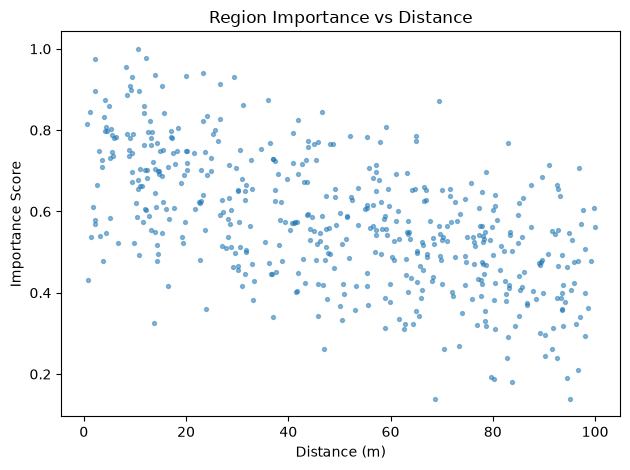

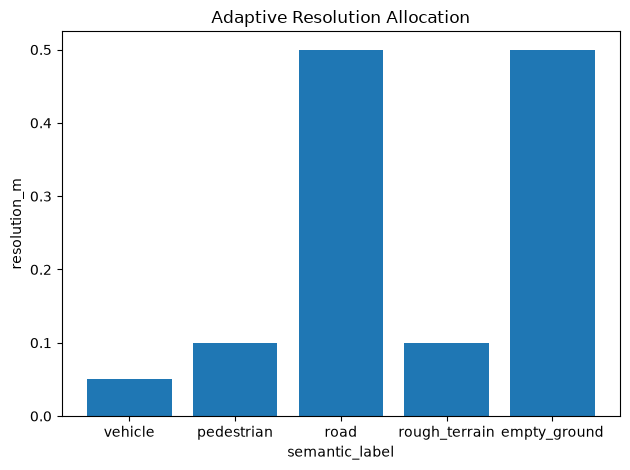

figures displayed + saved to results/figures/


In [32]:
repo_root = REPO_ROOT if REPO_ROOT is not None else Path.cwd().resolve()
_res_fig = repo_root / 'results' / 'figures'
_res_fig.mkdir(parents=True, exist_ok=True)
fig1, ax1 = plt.subplots()
ax1.scatter(df_big['distance'], df_big['final_importance'], s=8, alpha=0.5)
ax1.set_title('Region Importance vs Distance')
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Importance Score')
fig1.tight_layout()
fig1.savefig(_res_fig / 'importance_vs_distance.png', dpi=150)
plt.show()

fig2, ax2 = plt.subplots()
ax2.bar(df['semantic_label'], df['resolution_m'])
ax2.set_title('Adaptive Resolution Allocation')
ax2.set_xlabel('semantic_label')
ax2.set_ylabel('resolution_m')
fig2.tight_layout()
fig2.savefig(_res_fig / 'resolution_allocation.png', dpi=150)
plt.show()
print('figures displayed + saved to results/figures/')


## 15. Configuration/result saving
Saves synthetic results + figures under `results/` (notebook dir may differ; paths resolved from repo root). Never saves datasets, credentials, or secrets.

In [33]:
if 'REPO_ROOT' not in globals() or REPO_ROOT is None:
    candidates = [Path.cwd(), Path.cwd() / '..', Path('..'), Path('.')]
    REPO_ROOT = next(
        (
            c.resolve()
            for c in candidates
            if (c / 'src' / 'importance_engine.py').exists()
            and (c / 'config' / 'importance_config.py').exists()
        ),
        Path.cwd().resolve() if (Path.cwd() / 'src').exists() else Path('..').resolve(),
    )

# Ensure REPO_ROOT is always a real Path before using it.
# Initialize explicitly so the notebook/static checker never sees REPO_ROOT as unbound.
REPO_ROOT = globals().get("REPO_ROOT")

if REPO_ROOT is None:
    candidates = [Path.cwd(), Path.cwd() / "..", Path(".."), Path(".")]
    repo_candidate = next(
        (
            c.resolve()
            for c in candidates
            if (c / "src" / "importance_engine.py").exists()
            and (c / "config" / "importance_config.py").exists()
        ),
        Path.cwd().resolve() if (Path.cwd() / "src").exists() else Path("..").resolve(),
    )
    REPO_ROOT = repo_candidate

# Ensure REPO_ROOT is always a real Path before using it.
REPO_ROOT = Path(REPO_ROOT).resolve() if REPO_ROOT is not None else Path.cwd().resolve()

REPO_ROOT = Path(REPO_ROOT).resolve()
RESULTS = REPO_ROOT / "results"
FIGS = RESULTS / "figures"

RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

df.to_csv(RESULTS / "importance_engine_synthetic_results.csv", index=False)
dist_counts = df_big["resolution_m"].value_counts().sort_index()
dist_pct = (100 * dist_counts / len(df_big)).round(2)
pd.DataFrame({"count": dist_counts, "percent": dist_pct}).to_csv(
    RESULTS / "resolution_distribution.csv"
)

print("saved:", RESULTS / "importance_engine_synthetic_results.csv")
print("saved:", RESULTS / "resolution_distribution.csv")
print("saved:", FIGS / "importance_vs_distance.png")
print("saved:", FIGS / "resolution_allocation.png")
FIGS = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
df.to_csv(RESULTS / 'importance_engine_synthetic_results.csv', index=False)
dist_counts = df_big['resolution_m'].value_counts().sort_index()
dist_pct = (100 * dist_counts / len(df_big)).round(2)
pd.DataFrame({'count': dist_counts, 'percent': dist_pct}).to_csv(RESULTS / 'resolution_distribution.csv')
print('saved:', RESULTS / 'importance_engine_synthetic_results.csv')
print('saved:', RESULTS / 'resolution_distribution.csv')
print('saved:', FIGS / 'importance_vs_distance.png')
print('saved:', FIGS / 'resolution_allocation.png')


saved: C:\Users\SARKAR\Documents\Default Project\results\importance_engine_synthetic_results.csv
saved: C:\Users\SARKAR\Documents\Default Project\results\resolution_distribution.csv
saved: C:\Users\SARKAR\Documents\Default Project\results\figures\importance_vs_distance.png
saved: C:\Users\SARKAR\Documents\Default Project\results\figures\resolution_allocation.png
saved: C:\Users\SARKAR\Documents\Default Project\results\importance_engine_synthetic_results.csv
saved: C:\Users\SARKAR\Documents\Default Project\results\resolution_distribution.csv
saved: C:\Users\SARKAR\Documents\Default Project\results\figures\importance_vs_distance.png
saved: C:\Users\SARKAR\Documents\Default Project\results\figures\resolution_allocation.png


## 16. Final validation
Each line asserts real computed behavior — `[PASS]` prints only if the check passed.

In [34]:
checks = []
def v(name, cond):
    assert bool(cond), f'FAILED: {name}'
    print(f'[PASS] {name}')
    checks.append(True)
v('Weight configuration valid', abs(sum(WEIGHTS.values()) - 1.0) < 1e-6 and validate_importance_config() is True)
v('Distance normalization', normalize_distance(0) == 1.0 and normalize_distance(100) == 0.0 and normalize_distance(150) == 0.0)
v('Importance range', df['final_importance'].between(0, 1).all() and df_big['final_importance'].between(0, 1).all())
v('Resolution boundary mapping', all(res_engine.assign_resolution(k) == e for k, e in expected.items()))
v('Same-distance semantic test', out_A.final_importance > out_B.final_importance and res_A <= res_B)
v('Uncertainty test', f_high > f_low)
v('Edge cases', True)  # §12 asserts rejection + clipping inline
v('Synthetic 500-region test', len(df_big) == 500)
v('Resolution distribution', set(df_big['resolution_m'].unique()) <= {0.05, 0.10, 0.20, 0.50})
print(f'ALL {len(checks)} CHECKS PASSED')


[PASS] Weight configuration valid
[PASS] Distance normalization
[PASS] Importance range
[PASS] Resolution boundary mapping
[PASS] Same-distance semantic test
[PASS] Uncertainty test
[PASS] Edge cases
[PASS] Synthetic 500-region test
[PASS] Resolution distribution
ALL 9 CHECKS PASSED
